# 从可验证奖励中进行强化学习 (RLVR) 笔记

## 目录
1.  **从 RLHF 到 DPO: 寻求更简洁的方案**
    * RLHF 的基本流程
    * DPO：无需奖励模型的 RLHF
    * DPO 的推导过程
    * DPO 的梯度更新分析
2.  **实践中的强化学习算法**
    * PPO (Proximal Policy Optimization)
        * 理论与目标
        * 实践中的复杂性
        * 语言模型中的 PPO 实现细节
    * GRPO (Group Relative Policy Optimization)
        * 核心思想：简化 PPO
        * GRPO 的偏见与改进 (Dr. GRPO)
3.  **RLVR 案例研究**
    * Deepseek R1
        * 算法、设置与关键发现
        * SFT 初始化与 RL 阶段
        * 失败的尝试：PRM 和 MCTS
    * Kimi K1.5
        * 数据筛选与 SFT
        * 独特的 RL 算法
        * 长度控制与系统架构
    * Qwen 3
        * SFT 与低数据量 RL
        * 思维模式融合
        * 分阶段训练的效果

---

## 1. 从 RLHF 到 DPO: 寻求更简洁的方案
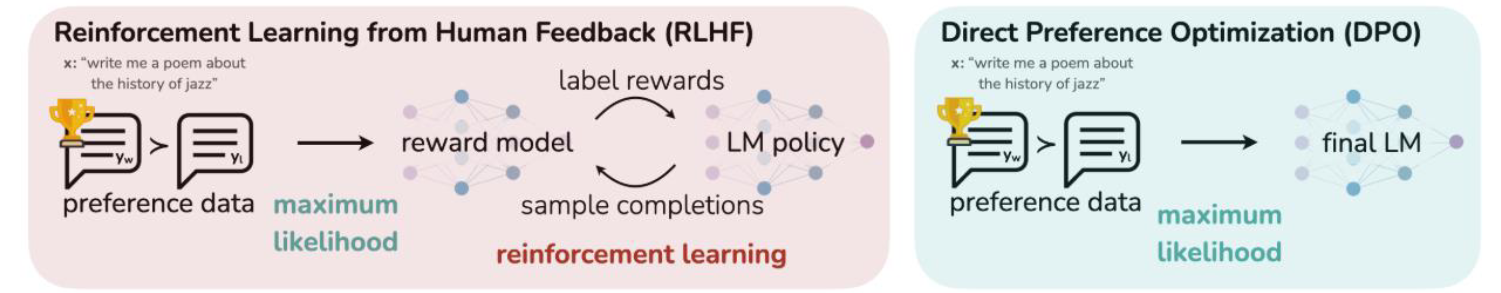
### RLHF (Reinforcement Learning from Human Feedback) 的基本流程
RLHF 是一种利用人类偏好数据来微调语言模型的方法。其标准流程如下：
1.  **收集偏好数据**: 针对同一个提示 (prompt) $x$，采样多个模型的输出，由人类标注者选出最优的回答 $y_w$ (winner) 和较差的回答 $y_l$ (loser)。
2.  **训练奖励模型**: 使用这些偏好数据 $(x, y_w, y_l)$ 训练一个奖励模型 $r_\phi(x,y)$，目标是让 $r_\phi(x,y_w) > r_\phi(x,y_l)$。
3.  **强化学习微调**: 使用奖励模型 $r_\phi$ 作为奖励函数，通过 PPO 等强化学习算法对语言模型策略 $\pi_\theta$ 进行优化，最大化奖励信号，同时用 KL 散度惩罚使其不过于偏离原始的参考模型 $\pi_{ref}$。

### DPO (Direct Preference Optimization)：无需奖励模型的 RLHF
DPO 旨在简化 PPO 流程，它实现了 **"RLHF without tears"**，其核心优势在于：
* **无需显式奖励模型**: DPO 直接在偏好数据上优化策略，绕过了训练独立奖励模型的步骤。
* **无需在线策略学习**: 摆脱了 PPO 中的 rollouts 和复杂的内外循环，变为一个简单的离线损失函数。

DPO 的核心思想可以概括为：
* 对偏好数据中的 "good stuff" (winning response $y_w$) 进行**对数损失的梯度上升**。
* 对 "bad stuff" (losing response $y_l$) 进行**加权的梯度下降**。

### DPO 的推导过程
DPO 的目标函数是从 RLHF 的优化目标推导出来的。

1.  **RLHF 的优化目标**:
    RLHF 的目标是最大化奖励，同时限制策略偏离参考模型。
    $$
    \max_{\pi_{\theta}}\mathbb{E}_{x\sim\mathcal{D},y\sim\pi_{\theta}(y|x)}[r_{\phi}(x,y)]-\beta\mathbb{D}_{KL}[\pi_{\theta}(y|x)||\pi_{ref}(y|x)]
    $$

2.  **最优策略的解析解**:
    假设策略空间是无参数的 (nonparametric assumption)，那么上述目标的最优策略 $\pi_r$ 具有以下形式：
    $$
    \pi_{r}(y|x)=\frac{1}{Z(x)}\pi_{ref}(y|x)\exp\left(\frac{1}{\beta}r(x,y)\right)
    $$
    其中 $Z(x)$ 是归一化因子。

3.  **反解隐式奖励**:
    从最优策略的表达式中，可以反解出奖励函数 $r(x,y)$：
    $$
    r(x,y)=\beta \log\frac{\pi_{r}(y|x)}{\pi_{ref}(y|x)}+\beta \log Z(x)
    $$
    这个关系是 DPO 的核心，它将奖励 $r$ 和策略 $\pi$ 直接关联起来。

4.  **构建 DPO 损失函数**:
    将这个隐式奖励函数代入标准的成对比较损失 (Bradley-Terry 模型) 中，即最大化 $y_w$ 的奖励高于 $y_l$ 的概率，得到最终的 DPO 目标函数：
    $$
    \mathcal{L}_{DPO}(\pi_{\theta};\pi_{ref})=-\mathbb{E}_{(x,y_{w},y_{l})\sim\mathcal{D}}\left[\log\sigma\left(\beta\log\frac{\pi_{\theta}(y_{w}|x)}{\pi_{ref}(y_{w}|x)}-\beta\log\frac{\pi_{\theta}(y_{l}|x)}{\pi_{ref}(y_{l}|x)}\right)\right]
    $$
    其中 $\sigma$ 是 sigmoid 函数。

### DPO 的梯度更新分析
DPO 损失函数对模型参数 $\theta$ 的梯度可以被分解为：
$$\nabla_{\theta}\mathcal{L}_{DPO}(\pi_{\theta};\pi_{ref}) = -\beta \mathbb{E}_{(x,y_w,y_l)\sim\mathcal{D}} \left[ \sigma(\dots) \underbrace{\left( \nabla_{\theta}\log\pi_{\theta}(y_w|x) - \nabla_{\theta}\log\pi_{\theta}(y_l|x) \right)}_{\text{增加 } y_w \text{ 的概率，降低 } y_l \text{ 的概率}} \right]$$
这个形式直观地体现了 DPO 的作用：
* **提高 $y_w$ 的似然**。
* **降低 $y_l$ 的似然**。
* 更新的权重由 $\sigma(\dots)$ 项调节，该项可以理解为**隐式奖励模型的预测误差**。当模型对 $(y_w, y_l)$ 的偏好判断错误时，权重会更高。

实验结果表明，DPO 的性能与精心调优的 PPO 相当，但实现更为简单。如今，大多数顶级的开源 RLHF 模型都采用了 DPO。

## 2. 实践中的强化学习算法

### PPO (Proximal Policy Optimization)
PPO 是 RLHF 和更广泛的 RL 任务中常用的策略梯度方法。

#### 理论与目标
PPO 通过在一个"裁剪" (clipping) 的目标函数上进行优化，来避免策略更新步子过大导致性能崩溃。其核心目标函数如下：
$$L(s, a, \theta_k, \theta) = \min\left( \frac{\pi_\theta(a|s)}{\pi_{\theta_k}(a|s)} A^{\pi_{\theta_k}}(s,a), \quad \text{clip}\left(\frac{\pi_\theta(a|s)}{\pi_{\theta_k}(a|s)}, 1-\epsilon, 1+\epsilon\right) A^{\pi_{\theta_k}}(s,a) \right)$$
* $\frac{\pi_\theta(a|s)}{\pi_{\theta_k}(a|s)}$ 是重要性采样权重。
* $A^{\pi_{\theta_k}}(s,a)$ 是**优势函数 (Advantage Function)**，表示在状态 $s$ 下采取动作 $a$ 相对于平均水平的好坏。
* `clip` 函数将概率比率限制在 $[1-\epsilon, 1+\epsilon]$ 范围内，通常 $\epsilon=0.2$。

#### 实践中的复杂性
尽管 PPO 理论上很优雅，但在实践中实现起来非常复杂且有很多细节，包括：
* **价值模型 (Value Model)**: 需要一个额外的模型 $V_\phi(s)$ 来估计状态的价值，并用于计算优势函数，这会消耗大量内存并需要额外调优。
* **在线 Rollouts**: 需要在当前策略下进行采样 (rollouts) 来收集经验，这使得算法是**在线**的，效率较低。
* **奖励塑造 (Reward Shaping)**: 在语言模型中，通常会将最终的序列奖励与每一步的 KL 惩罚结合起来，以维持稳定性。
* **广义优势估计 (GAE)**: 一种更稳定的优势函数计算方法，是 PPO 的一个关键组件。

### GRPO (Group Relative Policy Optimization)
GRPO 是一个新兴的 RL 算法，旨在进一步简化 PPO。

#### 核心思想：简化 PPO
GRPO 的主要创新在于**移除了价值模型和复杂的优势函数计算**。它保留了 PPO 的裁剪目标函数结构，但用一种非常简单的方式来计算优势 $A_i$：
* 对于一个 prompt，从当前策略中采样一组 $G$ 个输出 $\{o_1, o_2, \dots, o_G\}$。
* 计算每个输出的奖励 $\{r_1, r_2, \dots, r_G\}$。
* 优势 $A_i$ 被定义为该组内奖励的**z-score标准化值**。

**GRPO 的优势函数**:
$$A_i = \frac{r_i - \text{mean}(\{r_1, r_2, \dots, r_G\})}{\text{std}(\{r_1, r_2, \dots, r_G\})}$$

**GRPO 的目标函数**:
$$\mathcal{J}_{GRPO}(\theta) = \mathbb{E}_{q \sim P(Q), \{o_i\}_{i=1}^G \sim \pi_{\theta_{old}}(O|q)} \left[ \frac{1}{G}\sum_{i=1}^G \min\left( \frac{\pi_\theta(o_i|q)}{\pi_{\theta_{old}}(o_i|q)}A_i, \text{clip}(\dots)A_i \right) - \beta D_{KL}(\pi_\theta||\pi_{ref}) \right]$$

#### GRPO 的偏见与改进 (Dr. GRPO)
GRPO 的优势计算虽然简单，但引入了理论上的问题：
* **有偏基线 (Biased Baseline)**: 根据策略梯度理论，从奖励中减去的基线 (baseline) 不能依赖于当前采取的动作。GRPO 中的均值和标准差都依赖于当前批次的所有样本，因此它不是一个有效的无偏基线。
* **长度偏见**: 分母中的标准差项可能会导致模型过度关注那些奖励方差大的问题 (无论简单还是困难)，并且实验表明它会不必要地增长不正确答案的长度。

**Dr. GRPO (GRPO Done Right)** 提出了修正方案，其优势函数仅减去均值，移除了有偏的标准差项，从而变成了一个无偏的估计器。
$$\hat{A}_{i,j} = R(q_i, o_{i,j}) - \text{mean}(\{R(q_i, o_{i,k})\}_{k \ne j})$$
*(注：上式接近留一法均值，是无偏的)*

## 3. RLVR 案例研究

### Deepseek R1
Deepseek R1 是一个通过 RLVR 在推理任务上取得巨大成功的模型，其开源的配方引发了广泛关注。

* **核心算法**: R1 主要使用 **GRPO** 算法进行 RL 训练。
* **训练设置 (R1-zero)**:
    * **奖励**: 包含两部分：1) 准确性奖励 (答案是否正确)；2) 格式奖励 (是否使用 `<think>` 标签)。
    * **基础模型**: Deepseek-V3。
* **关键发现**:
    * **"Aha" 时刻**: 训练过程中观察到模型会自行修正错误，并输出类似 "Wait, wait, wait. That's an aha moment" 的文本。但后续分析表明，这种能力可能在基础模型中就已存在，且 GRPO 的长度偏见可能放大了这种现象。
    * **CoT 长度增长**: 训练过程中，思维链 (CoT) 的平均长度显著增加。
* **完整 R1 流程**:
    1.  **推理 SFT**: 使用长 CoT 数据进行监督微调。
    2.  **RL (GRPO)**: 在 SFT 模型上进行 GRPO 训练，并加入了一个**语言一致性奖励**来避免 CoT 中出现多语言混合的问题。
    3.  **SFT/RLHF**: 最后阶段，在通用任务上进行传统的 SFT 和 RLHF (同样使用 GRPO)。
* **失败的尝试**: 报告中提到，PRM (Process Reward Models) 和 MCTS (Monte Carlo Tree Search) 等更复杂的方法效果有限，且计算开销大。

### Kimi K1.5
Kimi K1.5 与 R1 同期发布，也通过 RLVR 实现了顶尖的性能。

* **数据筛选**:
    * **难度过滤**: 只选择那些模型在 best-of-8 采样中失败的难题进行训练。
    * **任务均衡**: 确保数据覆盖不同领域和学科。
* **独特的 RL 算法**:
    Kimi 团队从 DPO 的推导中获得灵感，设计了一种新的带基线的策略梯度算法。它将奖励函数用策略和参考模型表示，并使用平方损失作为代理损失。最终的梯度形式如下：
    $$
    \frac{1}{k}\sum_{j=1}^k \left( \nabla_\theta \log \pi_\theta(y_j, z_j|x) (r(x, y_j, y^*) - \bar{r}) - \frac{\tau}{2}\nabla_\theta \left( \log \frac{\pi_\theta(y_j, z_j|x)}{\pi_{\theta_k}(y_j, z_j|x)} \right)^2 \right)
    $$
* **长度控制**:
    为了压缩 CoT 的长度，Kimi 引入了一个显式的**长度奖励**。对于同一批次中的样本，较长的序列会获得负奖励，从而激励模型在保证正确的前提下生成更简洁的回答。
* **系统架构**:
    为了解决 RL 训练中推理 (rollout) 和训练 (gradient update) 交替导致的效率低下问题，Kimi 设计了一个混合部署框架，使用 vLLM 进行高效推理，使用 Megatron 进行训练，并通过共享内存快速切换。

### Qwen 3
Qwen 3 是最新的开源推理模型之一，其特点在于**数据效率极高**的 RLVR。

* **SFT 与低数据量 RL**:
    Qwen 3 的 RL 阶段**仅使用了 3995 个样本**。这得益于其精细的数据筛选策略，包括难度过滤、移除简单样本以及对 CoT 质量的人工筛选。
* **思维模式融合 (Thinking Mode Fusion)**:
    为了让模型能够按需生成 CoT，Qwen 3 在训练数据中混合了两种模式：
    1.  **思考模式**: `...{query}</think><im_end> ... <think>{thinking_content}</think>...`
    2.  **非思考模式**: `...{query}/no think<im_end> ... <think></think>...`
    通过这种方式，模型学会了根据指令决定是否进行显式的链式思考，并能通过一个特殊的停止标记来控制思考过程的长度。
* **分阶段训练的效果**:
    报告显示，不同的训练阶段对模型能力的影响不同。例如，在经过通用的 RLHF 训练后，模型在数学和 STEM 基准上的性能略有下降，但在通用任务和指令遵循方面的能力得到了提升。

